# Exercise no. 2: Windowing

Consider the signal $x(t) = cos(2 π 1000 t + π/4) + cos (2 π 1100 t + π/3)$.
Sample the signal with a sampling frequency $f_c=25 KHz$ with $L=25000$ samples.

Implement a Python script that:
- Constructs the sampled signal.
- Computes the spectrum (fft with $L$ points) and plots the amplitude spectrum* of:
    - the sampled signal;
    - the windowed signal adopting a rectangular window with length $N$ (i.e., consider the first $N$ samples of the signal);
    - the windowed signal adopting a Hamming window with length $N$.


Consider $N$ varying between 500 and 2000 (e.g., with a step of 500 samples) and discuss the obtained result.

*When plotting the amplitude spectrum, plot amplitudes normalized with respect to the maximum value and express this normalized value in dB, i.e., $20 log_{10} (|\cdot| / |\cdot|_{max})$.


__Hints__. Use numpy methods (e.g., _cos_), matplotlib.pyplot methods (e.g., _plot_), scipy.fft methods (_fft_), scipy.signal.windows methods (_hamming_). Consider encapsulating the relevant code within a function that accepts as input N, and call it each time with a different $N$ value.


__Optional__. Test also other windows (_bartlett_, _hann_, _blackman_ methods) from the module scipy.signal.windows (see the relevant documentation at https://docs.scipy.org/doc/scipy/reference/signal.windows.html#module-scipy.signal.windows), also when modifying the signal as $x(t) = 10 cos(2 π 1000 t + π/4) + cos (2 π 1100 t + π/3)$, i.e., a cosine associated to the relevant component, and the other cosine associated to a noise component of the signal.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal.windows import hamming
from scipy.fft import fft

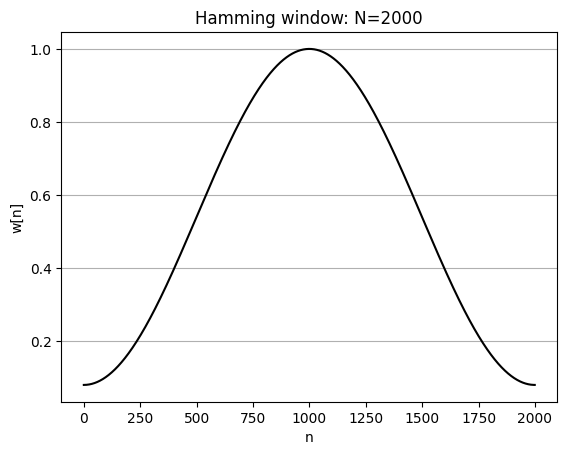

In [2]:
fc = 25000
N = 2000
L = 25000

n = np.arange(L)
x = np.cos(2*np.pi*1000*n/fc + np.pi/4) + np.cos(2*np.pi*1100*n/fc + np.pi/3)

F = np.arange(L)*fc / L

# spectrum of the signal x
X = fft(x) # no windowing N points
# spectrum of the truncated signal with a rect. window (i.e., spectrum of the first N points of x)
Xrect = fft(x[:N], L)

# defining N-point hamming window
w = hamming(N)

plt.figure()
plt.plot(np.arange(N), w, 'k')
plt.ylabel('w[n]')
plt.xlabel('n')
plt.grid(axis='y')
plt.title('Hamming window: N='+str(N))

# computing windowed signal (element-wise product between first N points of x and w)
xhamm = x[:N] * w
# spectrum of the truncated signal with a hamming window
Xhamm = fft(xhamm, L)

(-60.0, 0.0)

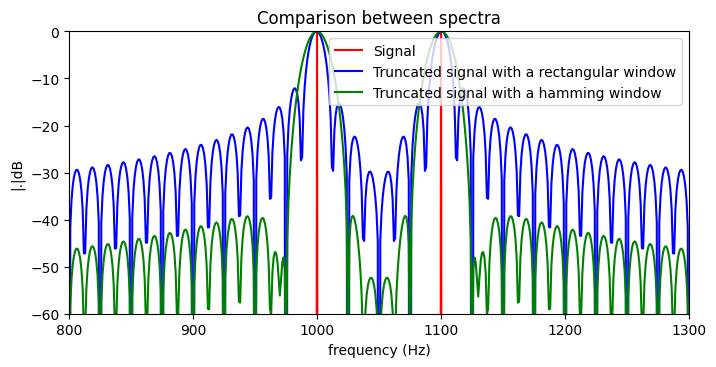

In [3]:
plt.figure(figsize=(8, 11/3)) # figsize=(8,11) is approx. A4 sheet (portrait)

tmp = 1/fc * np.abs(X[:int(L/2)])
plt.plot(F[:int(L/2)], 20*np.log10(tmp / np.max(tmp)), 'r')

tmp = 1/fc * np.abs(Xrect[:int(L/2)])
plt.plot(F[:int(L/2)], 20*np.log10(tmp / np.max(tmp)), 'b')

tmp = 1/fc * np.abs(Xhamm[:int(L/2)])
plt.plot(F[:int(L/2)], 20*np.log10(tmp / np.max(tmp)), 'g')

plt.title('Comparison between spectra')
plt.legend(['Signal',
           'Truncated signal with a rectangular window',
           'Truncated signal with a hamming window'])

plt.xlabel('frequency (Hz)')
plt.ylabel('|.|dB')
plt.xlim([800, 1300])
plt.ylim([-60, 0])
#plt.axis([800, 1300, -60, 0])

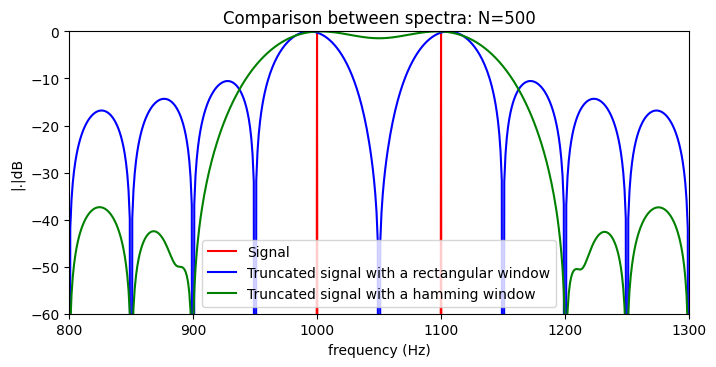

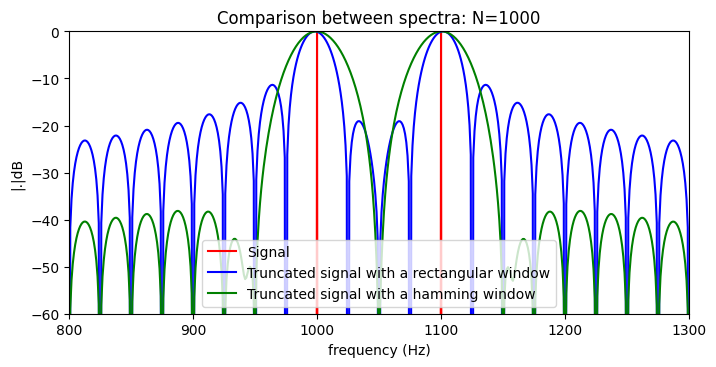

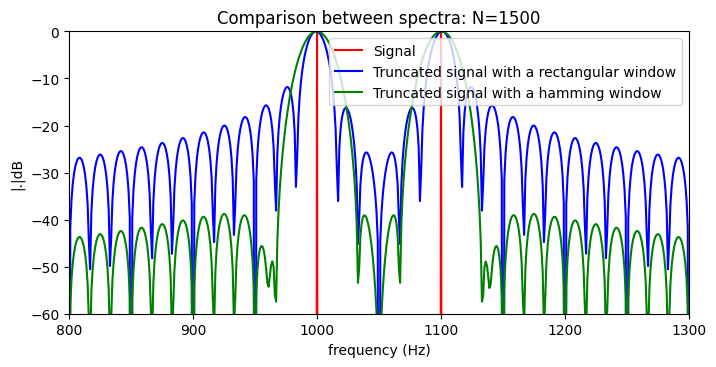

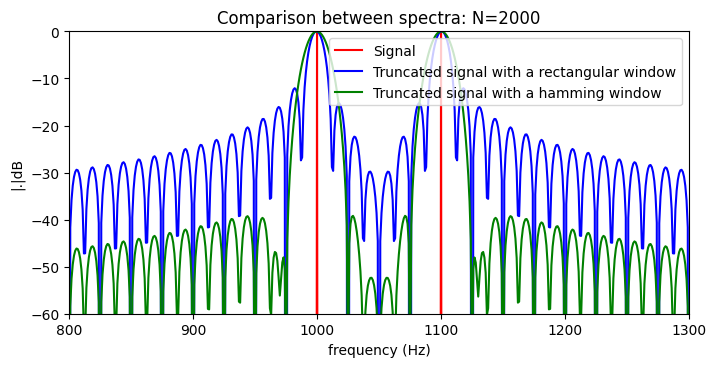

In [4]:
# Scaling up for many values of N (from 500 to 2000, choosing a coarse step of 500 for convenience)

def compare_spectra(N, L, fc):
    # This function performs the relevant computations with a fixed N. Accepting also L and fc as input.
    n = np.arange(L)
    x = np.cos(2*np.pi*1000*n/fc + np.pi/4) + np.cos(2*np.pi*1100*n/fc + np.pi/3)
    F = np.arange(L)*fc/L

    X = fft(x)

    Xrect = fft(x[:N], L)

    w = hamming(N)
    xhamm = x[:N] * w
    Xhamm = fft(xhamm, L)

    plt.figure(figsize=(8, 11/3)) # figsize=(8,11) is approx. A4 sheet (portrait)
    tmps = [1/fc * np.abs(X[:int(L/2)]),
            1/fc * np.abs(Xrect[:int(L/2)]),
            1/fc * np.abs(Xhamm[:int(L/2)])]
    cols = ['r', 'b', 'g']
    labels = ['Signal',
              'Truncated signal with a rectangular window',
              'Truncated signal with a hamming window']
    for i in np.arange(len(tmps)): # introducing a for loop for plotting each spectrum
        tmp = tmps[i]
        plt.plot(F[:int(L/2)],
                 20*np.log10(tmp / np.max(tmp)) ,
                 cols[i])

    plt.title('Comparison between spectra: N=' + str(N))
    plt.legend(labels)
    plt.xlabel('frequency (Hz)')
    plt.ylabel('|.|dB')
    plt.axis([800, 1300, -60, 0]) # lim axis at relevant frequencies


fc = 25000
N_array = np.arange(500, 2001, 500) # 500, 1000, ..., 2000
L = 25000 # or 25001

for N in N_array: # looping across different Ns
    compare_spectra(N, L, fc)